### Lab 7: Implementation of Amplitude Shift Keying (ASK) Modulation and Demodulation using Python

C:\Users\User\AppData\Local\Temp\ipykernel_19968\1065671995.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z = np.trapz(seg * carrier, t)


Transmitted: [1 0 1 0 1 0 1 0 1]
Received:    [1 0 1 0 1 0 1 0 1]


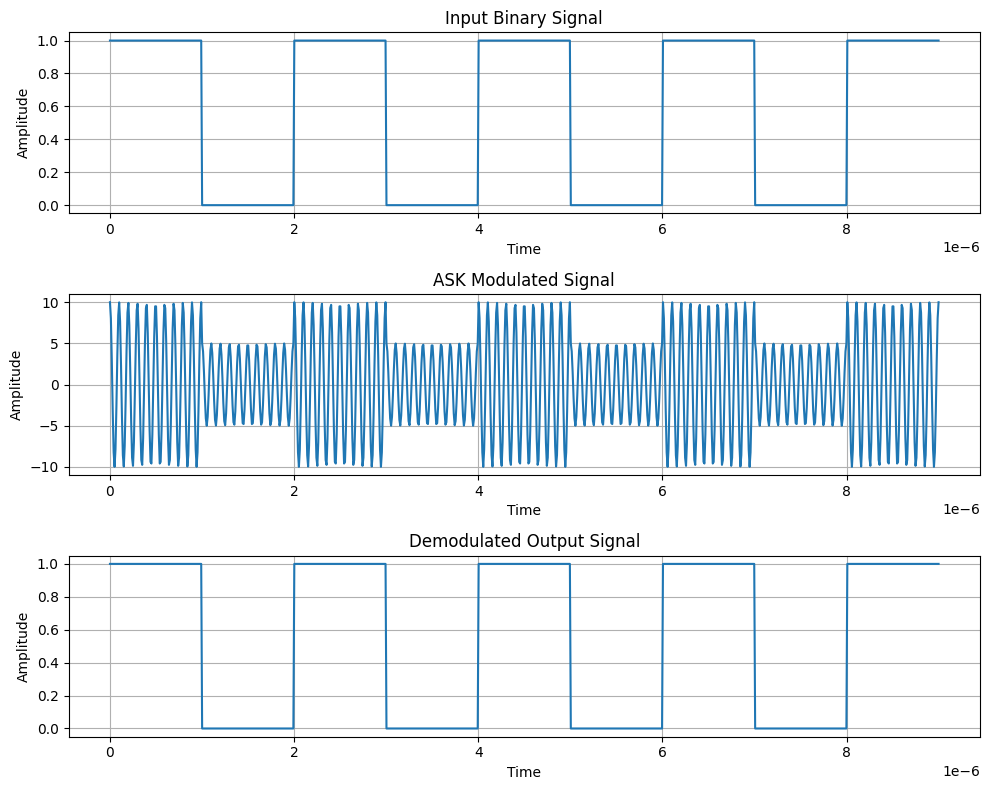

In [2]:
# Lab: ASK Modulation & Demodulation

import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
x = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1])  # Binary data
bp = 1e-6                                  # Bit duration

# ------------------ DIGITAL SIGNAL ------------------
bit = np.repeat(x, 100)                    # Expand bits
t1 = np.linspace(0, bp*len(x), len(bit))   # Time axis

# ------------------ ASK PARAMETERS ------------------
A1, A2 = 10, 5                             # Amplitudes (1 → high, 0 → low)
f = 10 / bp                                # Carrier frequency
t = np.linspace(0, bp, 100)                # Time for one bit

carrier = np.cos(2 * np.pi * f * t)        # Carrier signal

# ------------------ ASK MODULATION ------------------
m = np.concatenate([
    (A1 if i == 1 else A2) * carrier for i in x
])

t2 = np.linspace(0, bp*len(x), len(m))     # Time for modulated signal

# ------------------ DEMODULATION ------------------
mn = []  # Recovered bits

for i in range(0, len(m), 100):
    seg = m[i:i+100]                       # One bit segment
    
    # Correlation with carrier
    z = np.trapz(seg * carrier, t)
    
    # Threshold decision
    if (2 * z / bp) > 7.5:
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)

print("Transmitted:", x)
print("Received:   ", mn)

# ------------------ OUTPUT SIGNAL ------------------
bit_r = np.repeat(mn, 100)
t3 = np.linspace(0, bp*len(mn), len(bit_r))

# ------------------ PLOTTING ------------------
plt.figure(figsize=(10, 8))

# 1. Input Signal
plt.subplot(3,1,1)
plt.plot(t1, bit)
plt.title("Input Binary Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 2. ASK Modulated Signal
plt.subplot(3,1,2)
plt.plot(t2, m)
plt.title("ASK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 3. Demodulated Signal
plt.subplot(3,1,3)
plt.plot(t3, bit_r)
plt.title("Demodulated Output Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

### Lab:8 Implementation of Frequency Shift Keying (FSK) Modulation and Demodulation using Python.

C:\Users\User\AppData\Local\Temp\ipykernel_19968\3771443974.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z1 = np.trapz(seg * np.cos(2 * np.pi * f1 * t), t)
C:\Users\User\AppData\Local\Temp\ipykernel_19968\3771443974.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z2 = np.trapz(seg * np.cos(2 * np.pi * f2 * t), t)


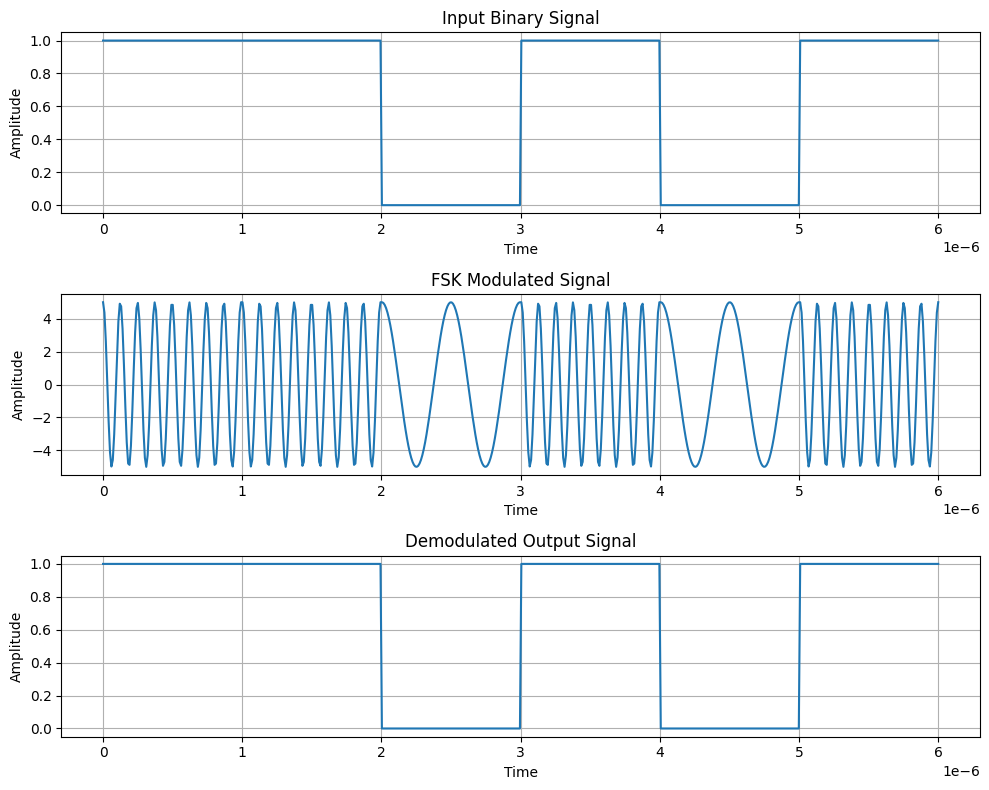

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
x = np.array([1, 1, 0, 1, 0, 1])   # Binary data
bp = 1e-6                          # Bit duration

# ------------------ DIGITAL SIGNAL ------------------
bit = np.repeat(x, 100)            # Expand each bit
t1 = np.linspace(0, bp * len(x), len(bit))  # Time axis

# ------------------ FSK PARAMETERS ------------------
A = 5                              # Amplitude
f1 = 8 / bp                        # Frequency for bit 1
f2 = 2 / bp                        # Frequency for bit 0
t = np.linspace(0, bp, 100)        # Time for one bit

# ------------------ FSK MODULATION ------------------
# Change frequency based on bit value
m = np.concatenate([
    A * np.cos(2 * np.pi * (f1 if i == 1 else f2) * t)
    for i in x
])

t2 = np.linspace(0, bp * len(x), len(m))  # Time axis for modulated signal

# ------------------ DEMODULATION ------------------
mn = []  # Recovered bits

for i in range(0, len(m), 100):
    seg = m[i:i+100]  # Take one bit segment
    
    # Correlation with both frequencies
    z1 = np.trapz(seg * np.cos(2 * np.pi * f1 * t), t)
    z2 = np.trapz(seg * np.cos(2 * np.pi * f2 * t), t)
    
    # Decision: choose higher correlation
    mn.append(1 if z1 > z2 else 0)

mn = np.array(mn)

# ------------------ OUTPUT SIGNAL ------------------
bit_r = np.repeat(mn, 100)         # Expand recovered bits
t3 = np.linspace(0, bp * len(mn), len(bit_r))

# ------------------ PLOTTING ------------------
plt.figure(figsize=(10, 8))

# 1. Input Signal
plt.subplot(3,1,1)
plt.plot(t1, bit)
plt.title("Input Binary Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 2. FSK Modulated Signal
plt.subplot(3,1,2)
plt.plot(t2, m)
plt.title("FSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 3. Demodulated Signal
plt.subplot(3,1,3)
plt.plot(t3, bit_r)
plt.title("Demodulated Output Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

### Lab: 9 Implementation of Phase Shift Keying (PSK) Modulation and Demodulation using Python.

C:\Users\User\AppData\Local\Temp\ipykernel_19968\2159153634.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z = np.trapz(seg * carrier, t)         # Correlation


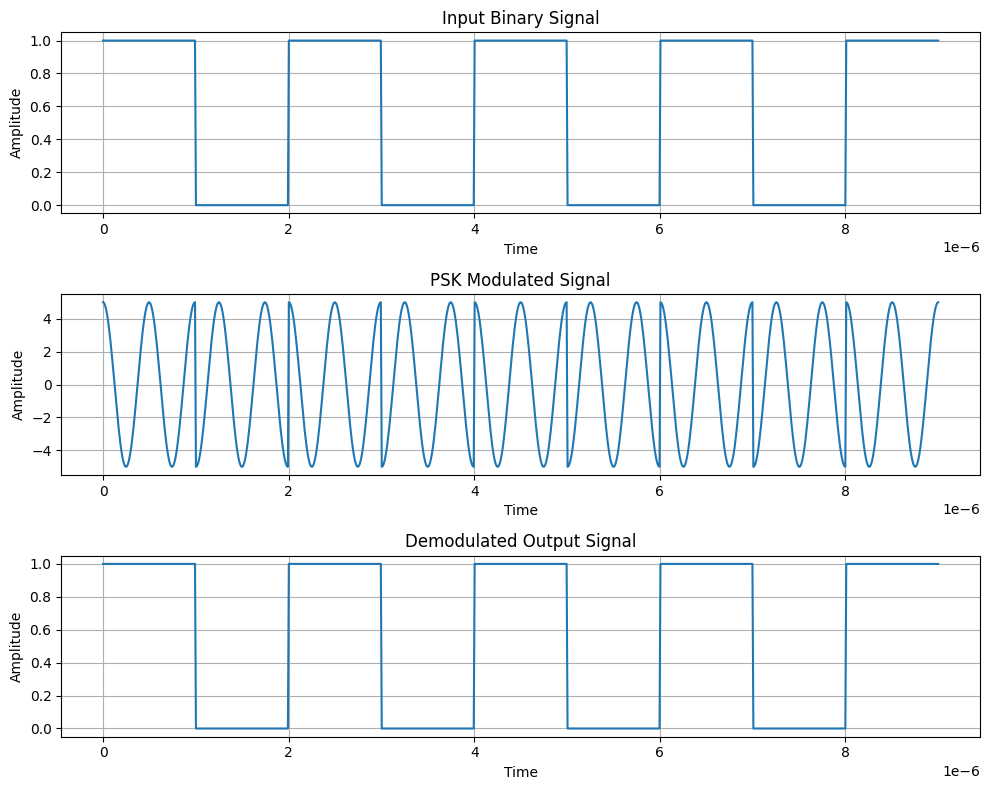

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
x = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1])  # Binary data
bp = 1e-6                                  # Bit duration

# ------------------ DIGITAL SIGNAL ------------------
bit = np.repeat(x, 100)                    # Expand bits
t1 = np.linspace(0, bp * len(x), len(bit))

# ------------------ PSK PARAMETERS ------------------
A = 5
f = 2 / bp                                 # Carrier frequency
t = np.linspace(0, bp, 100)

# ------------------ PSK MODULATION ------------------
# Phase change: 0° for bit 1, 180° for bit 0
m = np.concatenate([
    A * np.cos(2 * np.pi * f * t) if i == 1
    else A * np.cos(2 * np.pi * f * t + np.pi)
    for i in x
])

t2 = np.linspace(0, bp * len(x), len(m))

# ------------------ DEMODULATION ------------------
mn = []

for i in range(0, len(m), 100):
    seg = m[i:i+100]                       # One bit segment
    
    carrier = np.cos(2 * np.pi * f * t)    # Reference carrier
    z = np.trapz(seg * carrier, t)         # Correlation
    
    mn.append(1 if z > 0 else 0)           # Decision

mn = np.array(mn)

# ------------------ OUTPUT SIGNAL ------------------
bit_r = np.repeat(mn, 100)
t3 = np.linspace(0, bp * len(mn), len(bit_r))

# ------------------ PLOTTING ------------------
plt.figure(figsize=(10, 8))

# Input
plt.subplot(3,1,1)
plt.plot(t1, bit)
plt.title("Input Binary Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# PSK Modulated
plt.subplot(3,1,2)
plt.plot(t2, m)
plt.title("PSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Output
plt.subplot(3,1,3)
plt.plot(t3, bit_r)
plt.title("Demodulated Output Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

### Lab:10 Generation of Pulse Amplitude Modulation (PAM) using Sampling Pulse and Message Signal in Python

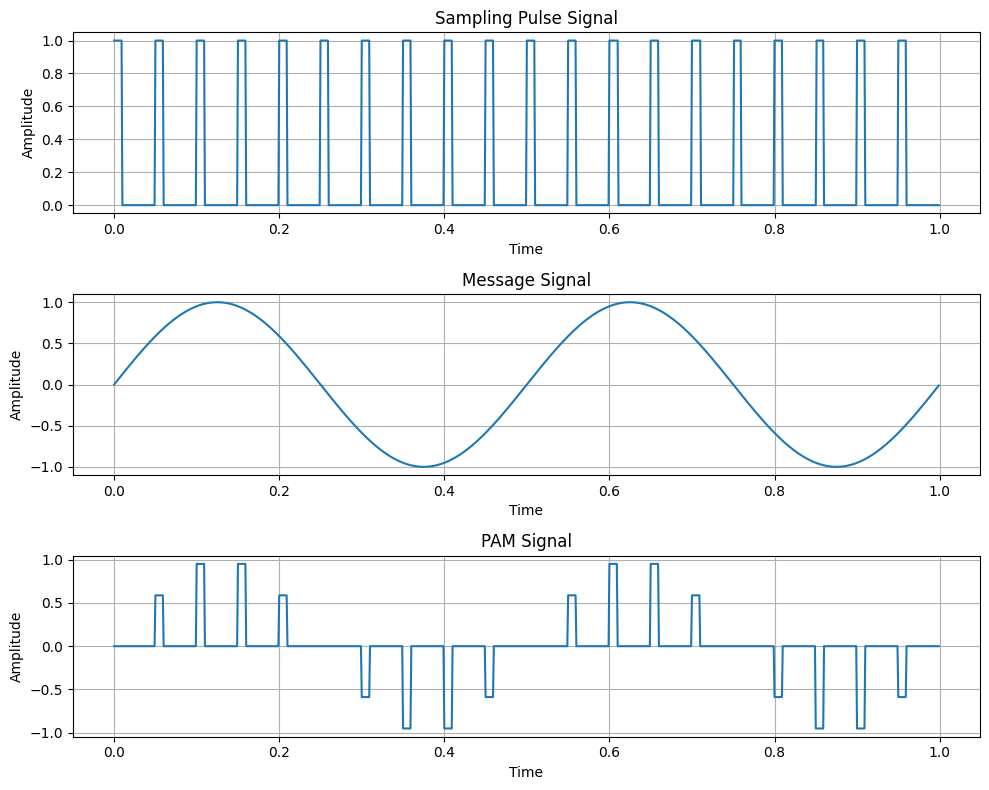

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ------------------ PARAMETERS ------------------
fc = 20          # Pulse (sampling) frequency
fm = 2           # Message signal frequency
fs = 1000        # Sampling frequency
t = 1            # Time duration
duty = 20        # Duty cycle (%)

# ------------------ TIME AXIS ------------------
n = np.arange(0, t, 1/fs)

# ------------------ SAMPLING PULSE ------------------
s = signal.square(2 * np.pi * fc * n, duty/100)
s[s < 0] = 0     # Convert to unipolar pulse (0 and 1)

# ------------------ MESSAGE SIGNAL ------------------
m = np.sin(2 * np.pi * fm * n)

# ------------------ PAM GENERATION ------------------
period_samp = int(len(n) / fc)                     # Samples per pulse
on_samp = int(np.ceil(period_samp * duty / 100))   # Pulse ON duration

pam = np.zeros(len(n))

for i in range(0, len(n), period_samp):
    pam[i:i+on_samp] = m[i]   # Sample & hold

# ------------------ PLOTTING ------------------
plt.figure(figsize=(10,8))

# 1. Sampling Pulse
plt.subplot(3,1,1)
plt.plot(n, s)
plt.title("Sampling Pulse Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 2. Message Signal
plt.subplot(3,1,2)
plt.plot(n, m)
plt.title("Message Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 3. PAM Signal
plt.subplot(3,1,3)
plt.plot(n, pam)
plt.title("PAM Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

### Lab 11: Generation of Unipolar Non-Return-to-Zero (NRZ) Line Coding using Python

Binary Data: [0 1 1 0 0 0 1 0 1 0]


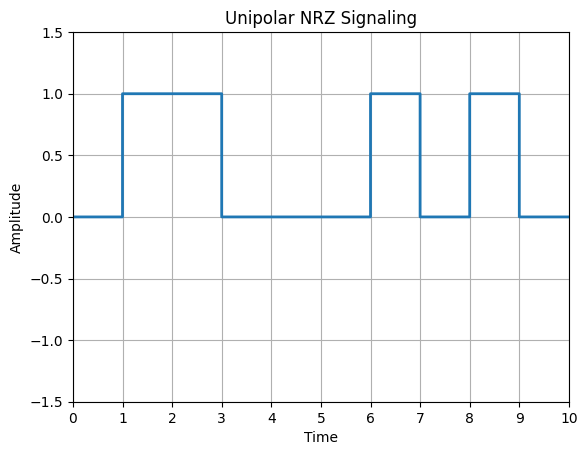

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
N = 10
n = np.array([0, 1, 1, 0, 0, 0, 1, 0, 1, 0])
print("Binary Data:", n)

# ------------------ MAPPING (Unipolar NRZ) ------------------
# 1 -> 1, 0 -> 0
nn = []

for m in range(N):
    if n[m] == 1:
        nn.append(1)
    else:
        nn.append(0)

# ------------------ SIGNAL SHAPING ------------------
t = np.arange(0, N, 0.01)   # Time axis
y = np.zeros(len(t))

i = 0
for j in range(len(t)):
    if t[j] < i + 1:
        y[j] = nn[i]
    else:
        i += 1
        y[j] = nn[i]

# ------------------ PLOTTING ------------------
plt.step(t, y, where='post', linewidth=2)
plt.axis([0, N, -1.5, 1.5])
plt.xticks(range(0, N+1))
plt.grid(True)
plt.title("Unipolar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

### Lab 12: Generation of Polar Non-Return-to-Zero (NRZ) Line Coding using Python

Binary Data: [0 1 0 1 0 1 0 1 1 1]


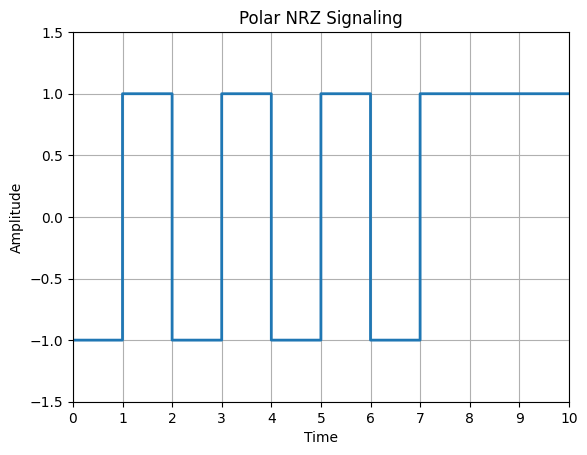

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
N = 10
n = np.array([0, 1, 0, 1, 0, 1, 0, 1, 1, 1])
print("Binary Data:", n)

# ------------------ MAPPING (Polar NRZ) ------------------
# 1 → +1, 0 → -1
nn = []

for m in range(N):
    if n[m] == 1:
        nn.append(1)
    else:
        nn.append(-1)

# ------------------ SIGNAL SHAPING ------------------
t = np.arange(0, N, 0.01)   # Time axis
y = np.zeros(len(t))

i = 0
for j in range(len(t)):
    if t[j] < i + 1:
        y[j] = nn[i]
    else:
        i += 1
        y[j] = nn[i]

# ------------------ PLOTTING ------------------
plt.step(t, y, where='post', linewidth=2)
plt.axis([0, N, -1.5, 1.5])
plt.xticks(range(0, N+1))
plt.grid(True)
plt.title("Polar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

### Lab:13 Generation of Unipolar Return-to-Zero (RZ) Line Coding using Python

Binary Data: [1 1 0 1 1 0 0 1 1 1]


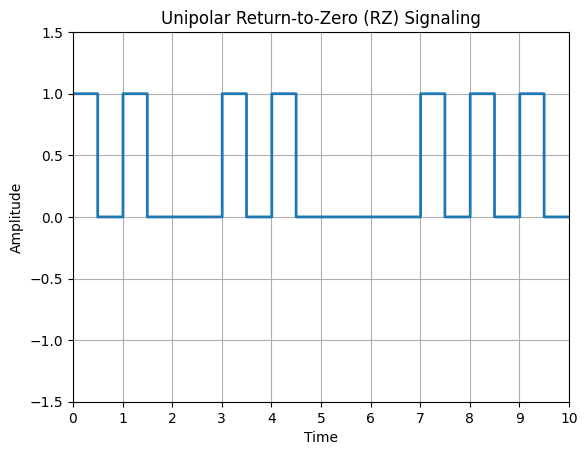

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
N = 10
n = np.array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1])
print("Binary Data:", n)

# ------------------ TIME AXIS ------------------
t = np.arange(0, N, 0.01)
y = np.zeros(len(t))

# ------------------ RZ SIGNAL GENERATION ------------------
i = 0
a = 0       # start of bit
b = 0.5     # منتصف point (half bit)

for j in range(len(t)):
    if t[j] >= a and t[j] < b:
        y[j] = n[i]      # first half → bit value (1 or 0)
    elif t[j] >= b and t[j] < i + 1:
        y[j] = 0         # second half → return to zero
    else:
        i += 1           # move to next bit
        a += 1
        b += 1

# ------------------ PLOTTING ------------------
plt.step(t, y, where='post', linewidth=2)
plt.axis([0, N, -1.5, 1.5])
plt.xticks(range(0, N+1))
plt.grid(True)
plt.title("Unipolar Return-to-Zero (RZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

### Lab 14: Generation of Bipolar Return-to-Zero (RZ) Line Coding using Python.

Binary Data: [0 0 1 1 0 0 0 1 1 1]


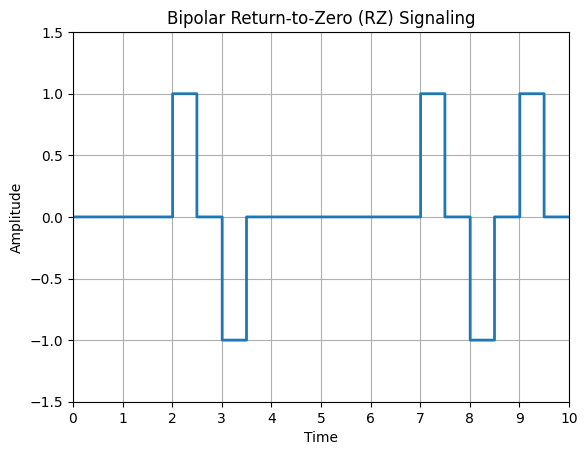

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
N = 10
n = np.array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1])
print("Binary Data:", n)

# ------------------ BIPOLAR MAPPING ------------------
# 1 → +1, -1 (alternating), 0 → 0
nn = []
f = 1   # starting polarity

for m in range(N):
    if n[m] == 1:
        nn.append(f)
        f *= -1          # alternate polarity
    else:
        nn.append(0)

# ------------------ SIGNAL GENERATION (RZ) ------------------
t = np.arange(0, N, 0.01)
y = np.zeros(len(t))

i = 0
a = 0
b = 0.5

for j in range(len(t)):
    if t[j] >= a and t[j] < b:
        y[j] = nn[i]     # first half → value (+1 / -1 / 0)
    elif t[j] >= b and t[j] < i + 1:
        y[j] = 0         # second half → return to zero
    else:
        i += 1
        a += 1
        b += 1

# ------------------ PLOTTING ------------------
plt.step(t, y, where='post', linewidth=2)
plt.axis([0, N, -1.5, 1.5])
plt.xticks(range(0, N+1))
plt.grid(True)
plt.title("Bipolar Return-to-Zero (RZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

### Lab 15: Generation of Manchester Line Coding using Python.

Binary Data: [0 0 1 0 0 0 0 0 0 1]


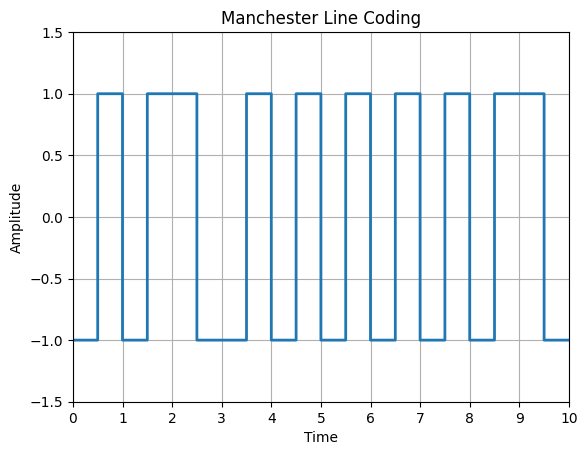

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ INPUT DATA ------------------
N = 10
n = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1])
print("Binary Data:", n)

# ------------------ MANCHESTER MAPPING ------------------
# 1 → [1, -1], 0 → [-1, 1]
nnn = []

for m in range(N):
    if n[m] == 1:
        nn = [1, -1]
    else:
        nn = [-1, 1]
    nnn.extend(nn)

# ------------------ SIGNAL GENERATION ------------------
t = np.arange(0, N, 0.01)
y = np.zeros(len(t))

i = 0
l = 0.5   # half bit duration

for j in range(len(t)):
    if t[j] < l:
        y[j] = nnn[i]
    else:
        i += 1
        l += 0.5
        y[j] = nnn[i]

# ------------------ PLOTTING ------------------
plt.step(t, y, where='post', linewidth=2)
plt.axis([0, N, -1.5, 1.5])
plt.xticks(range(0, N+1))
plt.grid(True)
plt.title("Manchester Line Coding")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()